# **Apprentissage du Pricing d'Options (BSM)**
## **Étude comparative : Réseau Standard vs Sobolev vs PINNs**


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import scipy.stats as si
import matplotlib.pyplot as plt

# ==========================================
# 1. Formule de Black-Scholes
# ==========================================
def black_scholes_call(S, K, T, r, sigma):
    """
    Calcule le prix théorique d'un Call Européen.
    """

    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    call_price = (S * si.norm.cdf(d1, 0.0, 1.0) -
                  K * np.exp(-r * T) * si.norm.cdf(d2, 0.0, 1.0))

    # Delta du Call : Delta = N(d1)
    delta = si.norm.cdf(d1)

    return call_price, delta

In [ ]:
# ==========================================
# 2. Génération des Données d'Entraînement
# ==========================================
def generate_data(n_samples=10000):
    """
    Génère des données aléatoires de marché et calcule les prix correspondants.
    """
    # S (Spot) : Entre 50 et 150
    S = np.random.uniform(50, 150, n_samples)
    # K (Strike) : Entre 50 et 150
    K = np.random.uniform(50, 150, n_samples)
    # T (Maturité) : Entre 0.1 an et 2 ans
    T = np.random.uniform(0.1, 2.0, n_samples)
    # r (Taux) : Entre 1% et 5%
    r = np.random.uniform(0.01, 0.05, n_samples)
    # sigma (Volatilité) : Entre 10% et 50%
    sigma = np.random.uniform(0.1, 0.5, n_samples)

    # Calcul des cibles (Prix réels et deltas)
    prices, deltas = black_scholes_call(S, K, T, r, sigma)


    # Normalisation
    X = np.stack([S/100.0, K/100.0, T, r, sigma], axis=1)
    y = prices.reshape(-1, 1) / 100
    dy = deltas.reshape(-1, 1)

    # Conversion en tenseurs PyTorch (float32)
    return (torch.tensor(X, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
            torch.tensor(dy, dtype=torch.float32))



In [ ]:
# ==========================================
# 3. L'Architecture du Réseau
# ==========================================
class PricingModel(nn.Module):
    def __init__(self, input_dim=5):
        super(PricingModel, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.LayerNorm(64), # Plus stable que BatchNorm pour les calculs de gradients
            nn.Tanh(),          # Indispensable pour avoir des dérivées (Grecs) lisses

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
def sobolev_loss(model, inputs, target_price, target_delta, lmbda=0.1):
    inputs.requires_grad_(True)
    pred_price = model(inputs)

    # 1. Gradient par rapport à l'entrée normalisée
    grads = torch.autograd.grad(pred_price.sum(), inputs, create_graph=True)[0]
    grad_S_norm = grads[:, 0:1]

    # 2. CORRECTION D'ÉCHELLE (Chain Rule)
    # On divise par 100 pour retrouver le "Vrai Delta" physique
    pred_delta_physique = grad_S_norm

    mse_price = nn.MSELoss()(pred_price, target_price)

    # On compare des pommes avec des pommes (Delta physique vs Delta cible)
    mse_delta = nn.MSELoss()(pred_delta_physique, target_delta)

    return mse_price + lmbda * mse_delta

In [ ]:
def pinn_loss(model, inputs, target_price, mu=0.1):
    inputs.requires_grad_(True)

    # 1. Récupération des inputs normalisés
    S_norm = inputs[:, 0:1]

    # 2. Prédiction (Prix normalisé)
    pred_price_norm = model(inputs)

    # 3. Calcul des gradients sur le monde normalisé
    grads = torch.autograd.grad(pred_price_norm.sum(), inputs, create_graph=True)[0]
    delta_pred = grads[:, 0:1] # d(P_norm)/d(S_norm) = Delta réel
    theta_pred_norm = grads[:, 2:3] # d(P_norm)/d(T)

    # Dérivée seconde (Gamma)
    # Gamma réel = d(Delta)/dS_phys = d(Delta)/d(S_norm * 100) = (1/100) * d(Delta)/d(S_norm)
    grad_delta = torch.autograd.grad(delta_pred.sum(), inputs, create_graph=True)[0]
    gamma_pred_norm = grad_delta[:, 0:1]

    # 4. PASSAGE AU MONDE PHYSIQUE pour l'équation
    # On remet tout à l'échelle pour que Black-Scholes fonctionne
    S_phys = S_norm * 100.0
    P_phys = pred_price_norm * 100.0

    # Delta est sans unité, il reste tel quel
    Delta_phys = delta_pred

    # Gamma a pour unité Price/S^2.
    # Avec notre normalisation : Gamma_phys = Gamma_output / 100.0
    Gamma_phys = gamma_pred_norm / 100.0

    # Theta a pour unité Price/Time.
    # Theta_phys = Theta_output * 100.0
    Theta_phys = theta_pred_norm * 100.0

    # Paramètres
    r = inputs[:, 3:4]     # r est en colonne 3
    sigma = inputs[:, 4:5] # sigma est en colonne 4

    # Équation de Black-Scholes (tous les termes en unités monétaires réelles)
    # dC/dt + 0.5*sigma^2*S^2*Gamma + r*S*Delta - r*C = 0
    # Note : inputs[:, 2] est T (maturité). Donc dC/dt = - dC/dT
    pde_residual = -Theta_phys + 0.5 * (sigma**2) * (S_phys**2) * Gamma_phys + r * S_phys * Delta_phys - r * P_phys

    mse_price = nn.MSELoss()(pred_price_norm, target_price)
    mse_pde = torch.mean(pde_residual**2)

    # On normalise le résidu PDE pour qu'il ne soit pas trop grand face au MSE
    # (Division par 100^2 car c'est une erreur au carré sur des prix non normalisés)
    return mse_price + mu * (mse_pde / 10000.0)

In [ ]:
# ==========================================
# 4. Entraînement
# ==========================================

def train_model(mode='standard', n_epochs=20):
    model = PricingModel()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Pour Standard, on garde le MSE simple
    base_criterion = nn.MSELoss()
    batch_size = 128

    print(f"--- Entraînement Mode: {mode.upper()} ---")



    for epoch in range(n_epochs):
        model.train()
        permutation = torch.randperm(X_train.size()[0])

        for i in range(0, X_train.size()[0], batch_size):
            indices = permutation[i:i+batch_size]
            batch_x = X_train[indices].clone().detach().requires_grad_(True)
            batch_y = y_train[indices]
            batch_delta = delta_train[indices]

            optimizer.zero_grad()

            if mode == 'standard':
                outputs = model(batch_x)
                loss = base_criterion(outputs, batch_y)

            elif mode == 'sobolev':
                # Appel de la fonction sobolev_loss définie précédemment
                loss = sobolev_loss(model, batch_x, batch_y, batch_delta, lmbda=1)

            elif mode == 'pinn':
                # Appel de la fonction pinn_loss définie précédemment
                loss = pinn_loss(model, batch_x, batch_y, mu=1)

            loss.backward()
            optimizer.step()

        # Évaluation (Validation)
        if (epoch+1) % 5 == 0:
            model.eval()
            with torch.no_grad(): # Pas besoin de gradients pour la validation standard
                val_preds = model(X_val)
                val_loss = base_criterion(val_preds, y_val)
                print(f'Epoch [{epoch+1}/{n_epochs}], Loss: {loss.item():.6f}, Val MSE: {val_loss.item():.6f}')

    return model

# On génère aussi les deltas réels pour Sobolev
X_train, y_train, delta_train = generate_data(n_samples=1000)
X_val, y_val, delta_val = generate_data(n_samples=2000)

model_std = train_model(mode='standard')
model_sob = train_model(mode='sobolev')
model_pinn = train_model(mode='pinn')

<generator object Module.parameters at 0x7c79372b6340>
--- Entraînement Mode: STANDARD ---
Epoch [5/20], Loss: 0.007679, Val MSE: 0.008360
Epoch [10/20], Loss: 0.007370, Val MSE: 0.006165
Epoch [15/20], Loss: 0.004283, Val MSE: 0.003893
Epoch [20/20], Loss: 0.002056, Val MSE: 0.001964
<generator object Module.parameters at 0x7c79372b6340>
--- Entraînement Mode: SOBOLEV ---
Epoch [5/20], Loss: 0.147842, Val MSE: 0.011456
Epoch [10/20], Loss: 0.014101, Val MSE: 0.002715
Epoch [15/20], Loss: 0.014368, Val MSE: 0.001290
Epoch [20/20], Loss: 0.009230, Val MSE: 0.000996
<generator object Module.parameters at 0x7c79372b6340>
--- Entraînement Mode: PINN ---
Epoch [5/20], Loss: 0.014553, Val MSE: 0.013623
Epoch [10/20], Loss: 0.011943, Val MSE: 0.009921
Epoch [15/20], Loss: 0.007517, Val MSE: 0.006261
Epoch [20/20], Loss: 0.004243, Val MSE: 0.003689


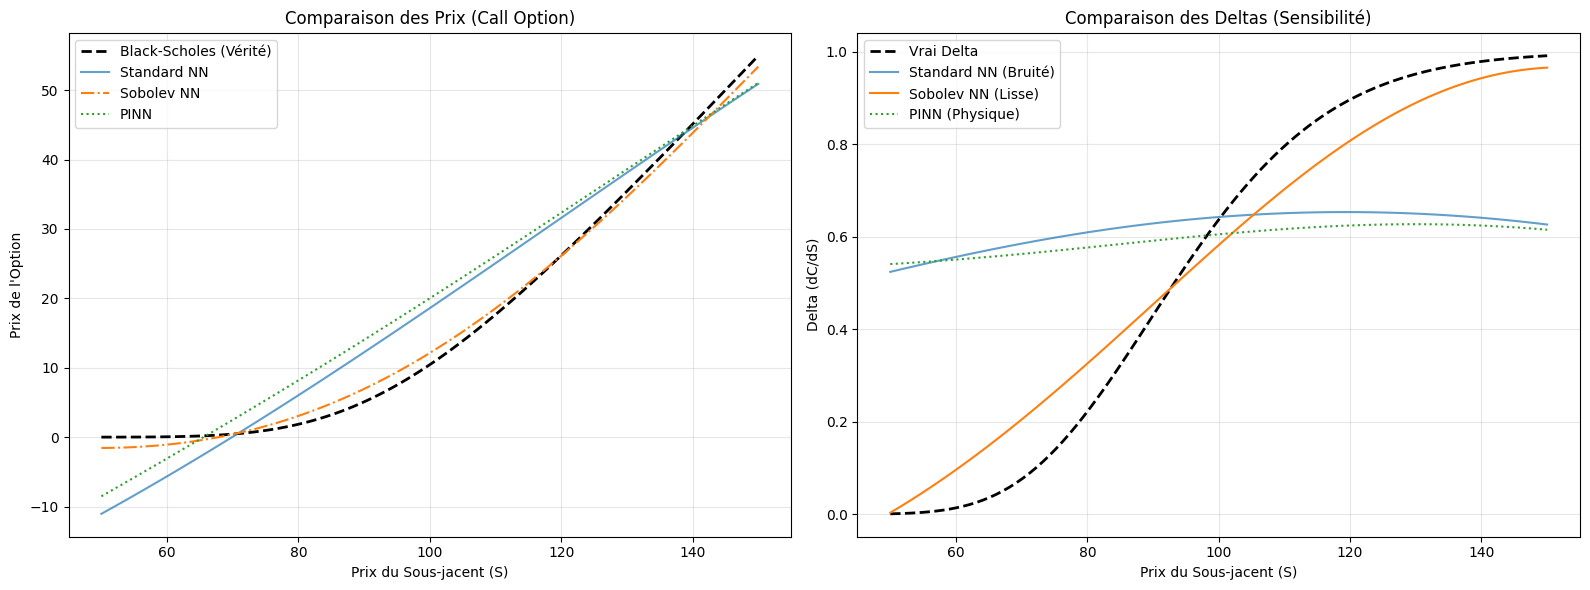

RMSE Standard NN sur les prix: 25.40054602028674 et sur les deltas: 0.38582488225006134
RMSE Sobolev NN sur les prix: 24.329666436188756 et sur les deltas: 0.49112733207817505
RMSE PINN: 24.95397987976876 sur les prix et sur les deltas: 0.381537669410269


In [ ]:
import matplotlib.pyplot as plt

def predict_price_and_delta(model, X_tensor):
    """
    Retourne le prix et le delta (gradient) pour un modèle donné.
    """
    model.eval()
    # On clone pour ne pas modifier le tenseur original et on active le gradient
    X = X_tensor.clone().detach().requires_grad_(True)

    # 1. Prédiction du prix
    price_pred = model(X)

    # 2. Calcul du gradient (Delta)
    # On veut d(Prix)/d(Input_S)
    grads = torch.autograd.grad(price_pred.sum(), X, create_graph=False)[0]

    # Attention : L'entrée S a été divisée par 100 dans le preprocessing.
    # Mathématiquement : dC/dS = (dC/dX) * (dX/dS) = grad * (1/100)
    # Mais si le modèle Sobolev a appris sur le Delta direct, il faut voir l'échelle.
    # Pour la comparaison visuelle, on prend le gradient brut de la 1ère colonne (S)
    delta_pred = grads[:, 0:1]

    return price_pred.detach().numpy()*100, delta_pred.detach().numpy()

# --- Paramètres du scénario ---
n_test = 100
S_vals = np.linspace(50, 150, n_test) # S varie
K_val = 100.0                         # Strike fixe
T_val = 1.0                           # 1 an maturité
r_val = 0.05                          # 5% taux
sigma_val = 0.2                       # 20% vol

# --- Préparation du tenseur d'entrée ---
# On respecte la même normalisation que l'entraînement !
# Rappel : S/100, K/100, T, r, sigma
X_test_np = np.stack([
    S_vals / 100.0,
    np.full(n_test, K_val) / 100.0,
    np.full(n_test, T_val),
    np.full(n_test, r_val),
    np.full(n_test, sigma_val)
], axis=1)

X_test_torch = torch.tensor(X_test_np, dtype=torch.float32)

# --- Vérité Terrain (Black-Scholes Analytique) ---
true_prices, true_deltas = black_scholes_call(
    S_vals,
    np.full(n_test, K_val),
    np.full(n_test, T_val),
    np.full(n_test, r_val),
    np.full(n_test, sigma_val)
)



# Supposons que vos modèles s'appellent : model_std, model_sob, model_pinn

# 1. Récupération des prédictions
price_std, delta_std = predict_price_and_delta(model_std, X_test_torch)
price_sob, delta_sob = predict_price_and_delta(model_sob, X_test_torch)
price_pinn, delta_pinn = predict_price_and_delta(model_pinn, X_test_torch)

# Note : Ajustement d'échelle du Delta si nécessaire selon votre normalisation
# Comme on a divisé S par 100, le gradient brut est 100x plus grand.
# Si vous avez entraîné Sobolev sur le vrai delta, le réseau compense déjà.
# Sinon, décommentez la ligne ci-dessous pour remettre à l'échelle :
delta_std = delta_std
delta_sob = delta_sob # Sobolev a souvent appris la bonne échelle directement
delta_pinn = delta_pinn


# 2. Affichage
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# --- Graphique 1 : Les Prix ---
ax[0].plot(S_vals, true_prices, 'k--', label='Black-Scholes (Vérité)', linewidth=2)
ax[0].plot(S_vals, price_std, label='Standard NN', alpha=0.7)
ax[0].plot(S_vals, price_sob, label='Sobolev NN', linestyle='-.')
ax[0].plot(S_vals, price_pinn, label='PINN', linestyle=':')
ax[0].set_title("Comparaison des Prix (Call Option)")
ax[0].set_xlabel("Prix du Sous-jacent (S)")
ax[0].set_ylabel("Prix de l'Option")
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# --- Graphique 2 : Les Deltas (La partie cruciale) ---
ax[1].plot(S_vals, true_deltas, 'k--', label='Vrai Delta', linewidth=2)
ax[1].plot(S_vals, delta_std, label='Standard NN (Bruité)', alpha=0.7)
ax[1].plot(S_vals, delta_sob, label='Sobolev NN (Lisse)')
ax[1].plot(S_vals, delta_pinn, label='PINN (Physique)', linestyle=':')

ax[1].set_title("Comparaison des Deltas (Sensibilité)")
ax[1].set_xlabel("Prix du Sous-jacent (S)")
ax[1].set_ylabel("Delta (dC/dS)")
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calcul RMSE
rmse_std_prices = np.sqrt(np.mean((true_prices - price_std)**2))
rmse_sob_prices = np.sqrt(np.mean((true_prices - price_sob)**2))
rmse_pinn_prices = np.sqrt(np.mean((true_prices - price_pinn)**2))

rmse_std_deltas = np.sqrt(np.mean((true_deltas - delta_std)**2))
rmse_sob_deltas = np.sqrt(np.mean((true_deltas - delta_sob)**2))
rmse_pinn_deltas = np.sqrt(np.mean((true_deltas - delta_pinn)**2))

print(f"RMSE Standard NN sur les prix: {rmse_std_prices} et sur les deltas: {rmse_std_deltas}")
print(f"RMSE Sobolev NN sur les prix: {rmse_sob_prices} et sur les deltas: {rmse_sob_deltas}")
print(f"RMSE PINN: {rmse_pinn_prices} sur les prix et sur les deltas: {rmse_pinn_deltas}")


In [ ]:
np.shape(delta_pinn)


(100, 1)

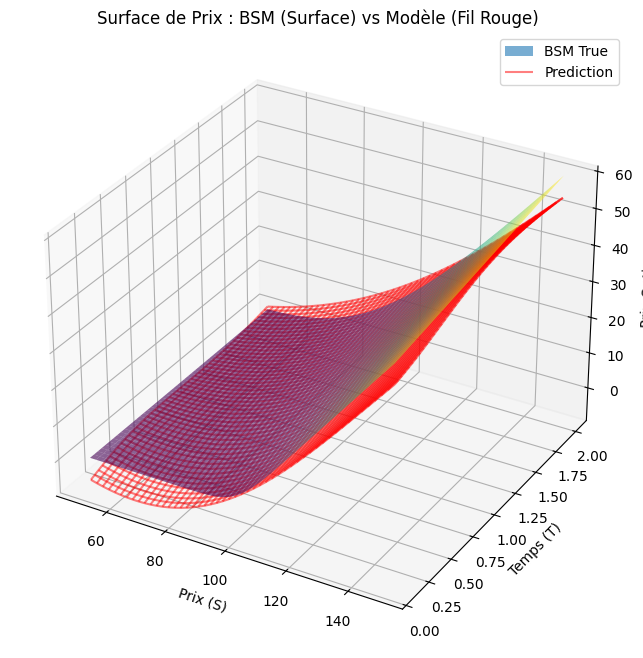

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_price_surface_3d(model=None, plot_truth=True):
    # 1. Création de la grille de points
    S_vals = np.linspace(50, 150, 50)
    T_vals = np.linspace(0.1, 2.0, 50)
    S_grid, T_grid = np.meshgrid(S_vals, T_vals)

    # Paramètres fixes pour la surface
    K_val = 100.0
    r_val = 0.05
    sigma_val = 0.2

    # 2. Préparation de la figure
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    # 3. Tracé de la Vérité Terrain (Black-Scholes)
    if plot_truth:
        C_true = black_scholes_call(S_grid, K_val, T_grid, r_val, sigma_val)[0] # [0] car la fonction renvoie (prix, delta)
        surf_true = ax.plot_surface(S_grid, T_grid, C_true, cmap='viridis', alpha=0.6, label='BSM True')
        # Hack pour la légende des surfaces
        surf_true._facecolors2d = surf_true._facecolor3d
        surf_true._edgecolors2d = surf_true._edgecolor3d

    # 4. Tracé de la Prédiction du Modèle (Optionnel)
    if model is not None:
        # On doit aplatir la grille pour passer dans le réseau
        # Rappel input: S/100, K/100, T, r, sigma

        # Aplatissement
        S_flat = S_grid.flatten()
        T_flat = T_grid.flatten()
        N = len(S_flat)

        # Construction du tenseur
        X_surf = np.stack([
            S_flat / 100.0,
            np.full(N, K_val) / 100.0,
            T_flat,
            np.full(N, r_val),
            np.full(N, sigma_val)
        ], axis=1)

        X_tensor = torch.tensor(X_surf, dtype=torch.float32)

        # Prédiction
        model.eval()
        with torch.no_grad():
            pred_flat = model(X_tensor).numpy().flatten()

        # Remise à l'échelle (x100 car on a normalisé y)
        pred_grid = pred_flat.reshape(S_grid.shape) * 100.0

        # Tracé de la surface prédite (en rouge fil de fer pour comparer)
        ax.plot_wireframe(S_grid, T_grid, pred_grid, color='red', alpha=0.5, label='Prediction')

    ax.set_title("Surface de Prix : BSM (Surface) vs Modèle (Fil Rouge)")
    ax.set_xlabel("Prix (S)")
    ax.set_ylabel("Temps (T)")
    ax.set_zlabel("Prix Option")
    plt.legend()
    plt.show()

# Utilisation :
plot_price_surface_3d(model=model_sob)
